In [1]:
library(dplyr)
library(ggplot2)
library(ggrepel)
library(ggrastr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘ggrepel’ was built under R version 4.3.3”
Warning message:
“package ‘ggrastr’ was built under R version 4.3.3”


In [2]:
 #age not scale; correct gender
olink <- read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/olink_age_liner_gender_FDR.csv",row.names=1) 
cytokine <- read.csv("/vol/projects/yzhang/500FG_aging/output/01_cytokine/cytokine_age_liner_gender_FDR.csv",row.names=1)
metabolite <- read.csv("/vol/projects/yzhang/500FG_aging/output/03_metabolite/metabolite_age_linear_gender_FDR.csv",row.names=1) 
methylation <- readRDS("/vol/projects/yzhang/500FG_aging/output/05_methylation/methylation_age_liner_gender_FDR.RDS") 
# rownames(methylation)<-methylation$X
# methylation$X <- NULL
methylation <- methylation %>% rename(feature = Mvalue)
hormone <- read.csv("/vol/projects/yzhang/500FG_aging/output/06_hormone/hormone_age_liner_gender_FDR.csv",row.names=1)
cellcounts <- read.csv("/vol/projects/yzhang/500FG_aging/output/07_cellcounts/cellcounts_age_rawless_gender_FDR.csv",row.names=1)  
immunoglobulin <- read.csv("/vol/projects/yzhang/500FG_aging/output/08_immunoglobulin/immunoglobulin_age_gender_FDR.csv",row.names=1)
microbiome <- read.csv("/vol/projects/yzhang/500FG_aging/output/10_microbiome/microbiome_age_gender_FDR.csv",row.names=1)
platelet<- read.csv("/vol/projects/yzhang/500FG_aging/output/09_platelet/platelet_age_gender_FDR.csv",row.names=1)

head(olink)
head(cytokine)
head(metabolite)
head(methylation)
head(cellcounts)
head(microbiome)
head(hormone)
head(immunoglobulin)
head(platelet)

,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,IL8,1.857226e-03,1.605897e-07,1.261852e-02,1.405159e-06,sig
Estimate1,VEGFA,3.326290e-04,2.074781e-03,8.924529e-04,6.051445e-03,sig
Estimate2,CD8A,-1.732231e-03,1.947852e-06,-9.891808e-03,1.136247e-05,sig
Estimate3,CDCP1,8.233146e-03,1.164648e-42,3.452471e-01,8.152538e-41,sig
Estimate4,CD244,-1.948333e-05,9.125587e-01,-7.742512e-07,9.257842e-01,no
Estimate5,IL7,1.341586e-03,3.960574e-02,1.881228e-03,7.108723e-02,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,IFNy_LPS_WB_48h,-1.489589e-03,0.0157429534,-2.685600e-03,0.057304350,no
Estimate1,IFNy_PHA_WB_48h,-1.248407e-03,0.1019912047,-1.237717e-03,0.257610692,no
Estimate2,IFNy_C.conidiaHK_WB_48h,-2.449299e-03,0.0004847994,-8.118050e-03,0.002757296,sig
Estimate3,IFNy_S.aureus_WB_48h,-1.828313e-03,0.0112181557,-3.565355e-03,0.050387503,no
Estimate4,IL1b_LPS_WB_48h,1.086956e-04,0.5573738995,2.759275e-05,0.768500377,no
Estimate5,IL1b_PHA_WB_48h,-9.867128e-05,0.8021676676,-9.446280e-06,0.912465722,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,Deoxynivalenol,-0.0021935538,1.463405e-02,-4.024372e-03,3.879725e-02,sig
Estimate1,Xenognosin A,0.0043140324,1.653234e-08,3.357036e-02,2.748502e-07,sig
Estimate2,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,-0.0022477068,8.116900e-02,-2.451371e-03,1.577902e-01,no
Estimate3,Cymarose,0.0002078031,6.635199e-01,3.701929e-05,7.537209e-01,no
Estimate4,Digitalose,0.0009722504,7.081403e-02,1.117972e-03,1.407462e-01,no
Estimate5,2-Naphthol,-0.0009047130,1.127605e-01,-8.575259e-04,2.036774e-01,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,cg00381604_BC11,-0.0013622451,0.41563686,-0.0005194049,0.7068243,no
Estimate1,cg00002271_BC21,-0.0013741588,0.11639210,-0.0012835694,0.3701592,no
Estimate2,cg00004581_TC21,0.0014710346,0.37799659,0.0006215299,0.6769167,no
Estimate3,cg09261435_BC21,-0.0011294722,0.55554164,-0.0002883355,0.8019698,no
Estimate4,cg00005473_TC21,-0.0007555015,0.38875621,-0.0003099994,0.6857682,no
Estimate5,cg00005474_TC21,0.0027755478,0.02548049,0.0044236464,0.1469979,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,Granulocytes,0.0053116240,6.575255e-04,1.690205e-02,1.919974e-03,sig
Estimate1,Monocytes (CD14+),0.0027371700,1.226924e-01,2.494061e-03,1.722413e-01,no
Estimate2,Classical monocytes (CD14++CD16-),0.0003365318,8.606286e-01,2.193657e-05,9.105201e-01,no
Estimate3,Non-classical monocytes (CD14++CD16+),0.0106594533,7.996762e-07,6.499160e-02,3.441537e-06,sig
Estimate4,Intermediate monocytes (CD14+CD16+),0.0112041293,2.481781e-08,8.521005e-02,2.013000e-07,sig
Estimate5,T cells (CD3+ CD56-),-0.0056417279,1.308008e-04,-2.190903e-02,4.151505e-04,sig


,feature,estimate,p,padj,value,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,PWY.6834..spermidine.biosynthesis.III,-0.0005871069,0.8736144,0.9974249,-3.445156e-05,no
2,FERMENTATION.PWY..mixed.acid.fermentation,-0.0015987720,0.6629898,0.9974249,-2.853698e-04,no
3,PWY.5686..UMP.biosynthesis,0.0009809679,0.7899729,0.9974249,1.004392e-04,no
4,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,-0.0019141214,0.6031429,0.9974249,-4.203023e-04,no
5,VALDEG.PWY..L.valine.degradation.I,-0.0003667833,0.9208083,0.9974249,-1.314212e-05,no
6,PPGPPMET.PWY..ppGpp.biosynthesis,-0.0006348761,0.8631562,0.9974249,-4.057532e-05,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,B_ADNC,-0.02501094,4.283096e-26,-0.63448350,3.854787e-25,sig
Estimate1,B_CORC,-0.02015736,2.037838e-17,-0.33644307,9.170270e-17,sig
Estimate2,B_DESC,-0.02048826,3.050586e-07,-0.13349364,6.663984e-07,sig
Estimate3,B_OHP,-0.01130764,3.791113e-03,-0.02737844,4.874289e-03,sig
Estimate4,B_PROG,-0.01576901,3.129267e-03,-0.03949439,4.693901e-03,sig
Estimate5,B_TESC,-0.01334730,2.096557e-09,-0.11583443,6.289670e-09,sig


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,IgG,-0.0008073224,0.4688979843,-0.0002655458,0.5358834106,no
Estimate1,IgA,0.0108772125,0.0001071556,0.0431823702,0.0008572451,sig
Estimate2,IgM,-0.0053371194,0.0352829504,-0.0077518196,0.0705659008,no
Estimate3,IgG1,-0.0028358536,0.0174610334,-0.0049852323,0.0465627556,sig
Estimate4,IgG2,0.0061802909,0.0008521803,0.0189702083,0.0034087213,sig
Estimate5,IgG3,-0.0035759784,0.1547176510,-0.0028981880,0.2475482415,no


,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,PLT_AP1,-0.0009190843,0.31381957,-0.0004625935,0.3835573,no
Estimate1,PLT_AF1,-0.0020392459,0.04864233,-0.0026775006,0.2012413,no
Estimate2,PLT_AP_AUC,0.0015022982,0.27211606,0.0008491678,0.3835573,no
Estimate3,PLT_AF_AUC,0.0022218860,0.26333792,0.0012875531,0.3835573,no
Estimate4,PLT_CP_AUC,-0.0011290399,0.45437515,-0.0003867926,0.4998127,no
Estimate5,PLT_CF_AUC,-0.0021594671,0.28776502,-0.0011681896,0.3835573,no


Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


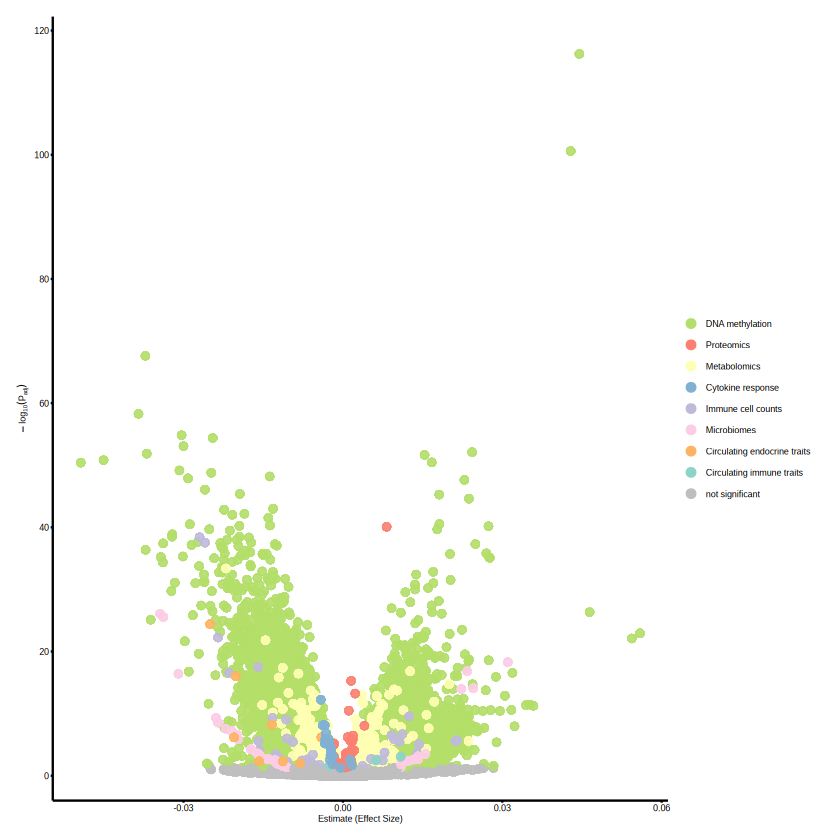

In [4]:
##nature style ###small size
# ------------------------------------------------------------------------------
# Add significance classification and -log10(padj) column
# ------------------------------------------------------------------------------
process_data <- function(data, level_name) {
  data %>%
    mutate(
      sig = ifelse(padj < 0.05, "significant", "not significant"),
      sig_direction = case_when(
        padj < 0.05 & estimate > 0 ~ "positive correlation",
        padj < 0.05 & estimate < 0 ~ "negative correlation",
        TRUE ~ "not significant"
      ),
      log_padj = -log10(padj),
      level = level_name
    )
}

# Layer display names (used for legend and labels)
titles <- c("DNA methylation", "Proteomics", "Metabolomics", "Cytokine response",
            "Immune cell counts", "Microbiomes", "Circulating endocrine traits", "Circulating immune traits")
# Datasets per layer: order must match titles 1:1
datasets <- list(
  methylation,    # DNA methylation
  olink,          # Proteomics
  metabolite,     # Metabolomics
  cytokine,       # Cytokine response
  cellcounts,     # Immune cell counts
  microbiome,     # Microbiomes
  hormone,        # Circulating endocrine traits
  immunoglobulin  # Circulating immune traits
)
names(datasets) <- titles

# Process and combine all layers
final_result_combined <- bind_rows(
  lapply(names(datasets), function(level_name) process_data(datasets[[level_name]], level_name))
)

# Group variable for color (significant vs not significant)
final_result_combined <- final_result_combined %>%
  mutate(level_sig = ifelse(sig == "not significant", "not significant", level))
color_palette <- setNames(
  # c("#B2DF8A", "#6A3D9A", "#FFFF99", "#FF7F00", "#A6CEE3", "#CAB2D6", "#e8d5b7", "#dcd6f7"),
     c("#B3DE69", "#FB8072", "#FFFFB3", "#80B1D3", "#BEBADA", "#FCCDE5", "#FDB462", "#8DD3C7"), 
  titles
)
legend_order <- c(titles, "not significant")
legend_colors <- c(color_palette, "not significant" = "grey")
colors <- final_result_combined %>%
  distinct(level_sig) %>%
  mutate(
    color = if_else(level_sig == "not significant", "grey", unname(color_palette[level_sig]))
  )
# Put Proteomics and Cytokine response on top layer: reorder data so they are drawn last
plot_data <- final_result_combined %>%
  mutate(.layer = case_when(
    level_sig %in% c("Proteomics", "Cytokine response") ~ 2L,
    TRUE ~ 1L
  )) %>%
  arrange(.layer)

# To add a title, uncomment: + ggtitle("Your title")
p <- ggplot(plot_data, aes(x = estimate, y = log_padj)) +
  #geom_point(aes(color = level_sig), size = 2, alpha = 0.9) +
  geom_point_rast(aes(color = level_sig), size = 2, alpha = 0.9, raster.dpi = 600)+ ###change the format of dots drawing
  scale_color_manual(values = legend_colors, breaks = legend_order) +
  scale_x_continuous(
    "Estimate (Effect Size)",
    expand = expansion(mult = 0.05)
  ) +
  scale_y_continuous(
    expression(-log[10](P[adj])),
    limits = c(-4, NA),
    expand = expansion(mult = c(0, 0.05)),
    breaks = scales::extended_breaks(n = 8)
  ) +
theme_classic(base_size = 5) +
  theme(
    axis.title = element_text(size = 5, colour = "black"),
    axis.text = element_text(size = 5, colour = "black"),
    axis.line = element_line(size = 0.5, colour = "black"),
    axis.ticks = element_line(size = 0.5, colour = "black"),
    plot.margin = margin(10, 10, 10, 10),
    legend.position = "right",
    legend.title = element_blank(),
    legend.key = element_rect(fill = "white", colour = NA),
    legend.key.size = unit(0.45, "cm"),
    legend.text = element_text(size = 5),
    legend.spacing.y = unit(2, "pt"),
    panel.background = element_rect(fill = "white", colour = NA)
  ) +
  guides(color = guide_legend(override.aes = list(size = 2, alpha = 1)))

# 2) Replace the two ggsave + print lines with:
fig_w_mm <- 88
fig_h_mm <- 88 * 7 / 10  # same aspect as 10x7 in
ggsave("/vol/projects/yzhang/500FG_aging/output/13_volcano_combined/multi_level_volcano_gender_complete_nature_small.pdf", plot = p, width = fig_w_mm, height = fig_h_mm, units = "mm")
ggsave("/vol/projects/yzhang/500FG_aging/output/13_volcano_combined/multi_level_volcano_gender_complete_nature_small.png", plot = p, width = fig_w_mm, height = fig_h_mm, units = "mm", dpi = 300)
print(p)


In [5]:
save.image("/vol/projects/yzhang/500FG_aging/output/13_volcano_combined/multi_level_volcano_gender_complete.Rdata")